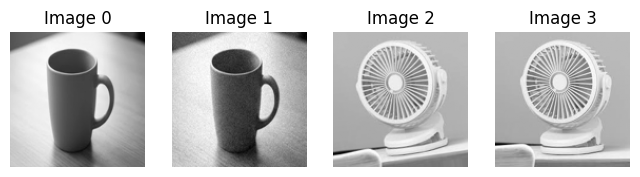

In [68]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc, confusion_matrix

def load_image(path, size=(128,128)):
    img = Image.open(path).convert('L')
    img = img.resize(size)
    return np.array(img)

# Dataset
images = ["image (25).png", "image (26).png", "image (27).png", "image (28).png"]

plt.figure(figsize=(8,4))
for i, path in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(load_image(path), cmap='gray')
    plt.title(f"Image {i}")
    plt.axis('off')
plt.show()

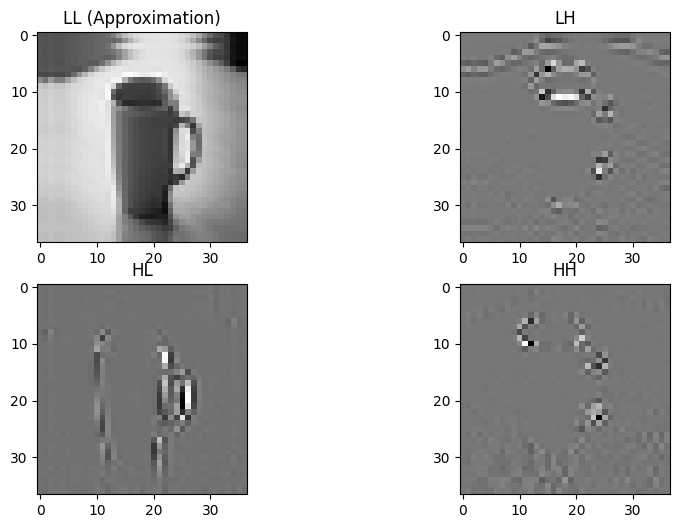

In [69]:
img = load_image("image (25).png")

#Chọn loại db càng cao thì chất lượng lọc nhiễu càng tốt, lv càng cao thì quy mô quan sát càng lớn 
#coeffs = pywt.wavedec2(img, 'db1', level=2)
#coeffs = pywt.wavedec2(img, 'db4', level=5)
coeffs = pywt.wavedec2(img, 'db4', level=2)
cA, (cH, cV, cD) = coeffs[0], coeffs[1]

plt.figure(figsize=(10,6))

#LL lọc thông thấp cả hàng và cột chứa đặc trưng chính của ảnh. Nó giống phiên bản thu nhỏ và làm mờ của ảnh gốc.
plt.subplot(2,2,1)
plt.imshow(cA, cmap='gray')
plt.title("LL (Approximation)")

# LH lọc thông thấp theo hàng và thông cao theo cột. Nó làm nổi bật các đường nét nằm ngang.
plt.subplot(2,2,2)
plt.imshow(cH, cmap='gray')
plt.title("LH")

#HL lọc thông cao theo hàng và thông thấp theo cột. Nó làm nổi bật các đường nét thẳng đứng.
plt.subplot(2,2,3)
plt.imshow(cV, cmap='gray')
plt.title("HL")

#HH lọc thông cao trên cả hàng và cột. Nó giữ lại các chi tiết theo phương chéo.
plt.subplot(2,2,4)
plt.imshow(cD, cmap='gray')
plt.title("HH")

plt.show()

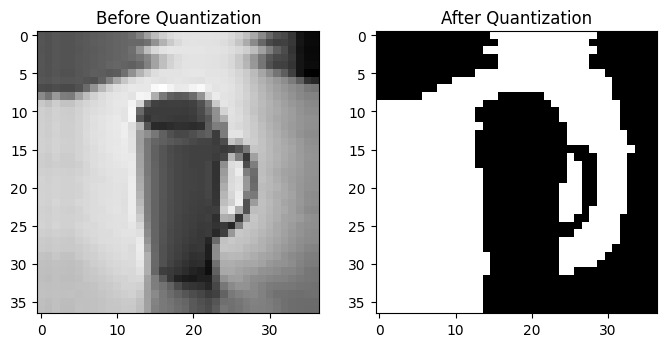

Median value: 633.1982460817454


In [70]:
#Tìm trung vị của tất cả điểm ảnh trong mảng cA (điểm nào sáng hơn trung vị thành màu trắng, ngược lại thành màu đen)
#Biến đổi mỗi điểm ảnh từ 256 mức về còn 2 mức(0,1) 
median = np.median(cA)
binary = (cA > median).astype(int)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cA, cmap='gray')
plt.title("Before Quantization")

plt.subplot(1,2,2)
plt.imshow(binary, cmap='gray')
plt.title("After Quantization")

plt.show()

print("Median value:", median)

In [71]:
#Flatten trải dài ma trận 2 chiều thành mảng 1 chiều 
hash_bits = binary.flatten()

print("Hash length:", len(hash_bits))
print("First 50 bits:", hash_bits[:50])

Hash length: 1369
First 50 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [72]:
def wavelet_hash(path, wavelet, show=True):
    img = load_image(path)
    coeffs = pywt.wavedec2(img, wavelet, level=2)
    cA = coeffs[0]
    median = np.median(cA)
    binary = (cA > median).astype(int).flatten()
    
    return binary

# Tính hash cho từng ảnh và hiển thị
hashes = []
for i, img_path in enumerate(images):
    h = wavelet_hash(img_path, 'db4')
    hashes.append(h)
    print(f"Image {i} hash (first 20 bits):", h[:20])

Image 0 hash (first 20 bits): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
Image 1 hash (first 20 bits): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
Image 2 hash (first 20 bits): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Image 3 hash (first 20 bits): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [73]:
def hamming_distance(h1, h2):
    return np.sum(h1 != h2)

print("Hamming distances:")

for i in range(len(images)):
    for j in range(i+1, len(images)):
        dist = hamming_distance(hashes[i], hashes[j])
        print(f"Image {i} vs {j} = {dist}")

Hamming distances:
Image 0 vs 1 = 52
Image 0 vs 2 = 754
Image 0 vs 3 = 778
Image 1 vs 2 = 772
Image 1 vs 3 = 786
Image 2 vs 3 = 190


In [74]:
# Threshold để quyết định giống hay khác
threshold = 200

# Tạo tất cả cặp ảnh (i < j)
num_images = len(hashes)
all_pairs = [(i, j) for i in range(num_images) for j in range(i+1, num_images)]

# Ground truth 
ground_truth = {
    (0,1): 1,
    (0,2): 0,
    (0,3): 0,
    (1,2): 0,
    (1,3): 0,
    (2,3): 1
}

y_true = []
y_pred = []
scores = []

print("\n===== IMAGE SEARCH PREDICTION =====")
for i, j in all_pairs:
    dist = hamming_distance(hashes[i], hashes[j])
    pred = 1 if dist < threshold else 0
    y_pred.append(pred)
    
    # Lấy nhãn thật nếu có
    true_label = ground_truth.get((i,j), None)
    y_true.append(true_label)

    scores.append(-dist)
    
    print(f"Image {i} vs {j} | Distance={dist} | Pred={pred} | True={true_label}")


===== IMAGE SEARCH PREDICTION =====
Image 0 vs 1 | Distance=52 | Pred=1 | True=1
Image 0 vs 2 | Distance=754 | Pred=0 | True=0
Image 0 vs 3 | Distance=778 | Pred=0 | True=0
Image 1 vs 2 | Distance=772 | Pred=0 | True=0
Image 1 vs 3 | Distance=786 | Pred=0 | True=0
Image 2 vs 3 | Distance=190 | Pred=1 | True=1


In [75]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Độ nhạy):", recall)
print("Specificity (Độ đặc hiệu):", specificity)

Accuracy: 1.0
Precision: 1.0
Recall (Độ nhạy): 1.0
Specificity (Độ đặc hiệu): 1.0


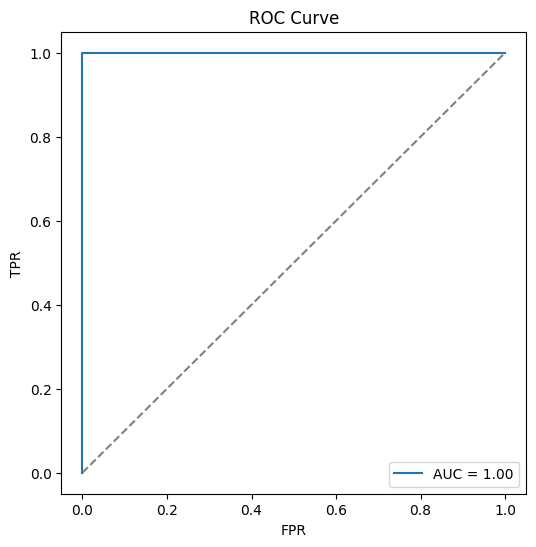

In [76]:
fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [77]:
wavelets = ['haar', 'db2', 'db4']

threshold = 100 

ground_truth = {
    (0,1): 1,
    (0,2): 0,
    (0,3): 0,
    (1,2): 0,
    (1,3): 0,
    (2,3): 1
}

print("===== SO SÁNH WAVELET =====")

for w in wavelets:
    print(f"--- Wavelet: {w} ---")
    
    hashes = []
    for i, img in enumerate(images):
        h = wavelet_hash(img, wavelet=w)
        hashes.append(h)

    num_images = len(hashes)
    all_pairs = [(i, j) for i in range(num_images) for j in range(i+1, num_images)]

    print("===== IMAGE SEARCH PREDICTION =====")
    for i, j in all_pairs:
        dist = hamming_distance(hashes[i], hashes[j])
        pred = 1 if dist < threshold else 0
        true_label = ground_truth.get((i,j), None)

        print(f"Image {i} vs {j} | Distance={dist} | Pred={pred} | True={true_label}")

===== SO SÁNH WAVELET =====
--- Wavelet: haar ---
===== IMAGE SEARCH PREDICTION =====
Image 0 vs 1 | Distance=56 | Pred=1 | True=1
Image 0 vs 2 | Distance=518 | Pred=0 | True=0
Image 0 vs 3 | Distance=524 | Pred=0 | True=0
Image 1 vs 2 | Distance=538 | Pred=0 | True=0
Image 1 vs 3 | Distance=538 | Pred=0 | True=0
Image 2 vs 3 | Distance=154 | Pred=0 | True=1
--- Wavelet: db2 ---
===== IMAGE SEARCH PREDICTION =====
Image 0 vs 1 | Distance=58 | Pred=1 | True=1
Image 0 vs 2 | Distance=590 | Pred=0 | True=0
Image 0 vs 3 | Distance=630 | Pred=0 | True=0
Image 1 vs 2 | Distance=608 | Pred=0 | True=0
Image 1 vs 3 | Distance=642 | Pred=0 | True=0
Image 2 vs 3 | Distance=196 | Pred=0 | True=1
--- Wavelet: db4 ---
===== IMAGE SEARCH PREDICTION =====
Image 0 vs 1 | Distance=52 | Pred=1 | True=1
Image 0 vs 2 | Distance=754 | Pred=0 | True=0
Image 0 vs 3 | Distance=778 | Pred=0 | True=0
Image 1 vs 2 | Distance=772 | Pred=0 | True=0
Image 1 vs 3 | Distance=786 | Pred=0 | True=0
Image 2 vs 3 | Distan


===== IMAGE SEARCH =====
Image: image (27).png | Distance: 0
Image: image (28).png | Distance: 190
Image: image (25).png | Distance: 754
Image: image (26).png | Distance: 772

===== SIMILAR IMAGES =====
Image: image (27).png | Distance: 0


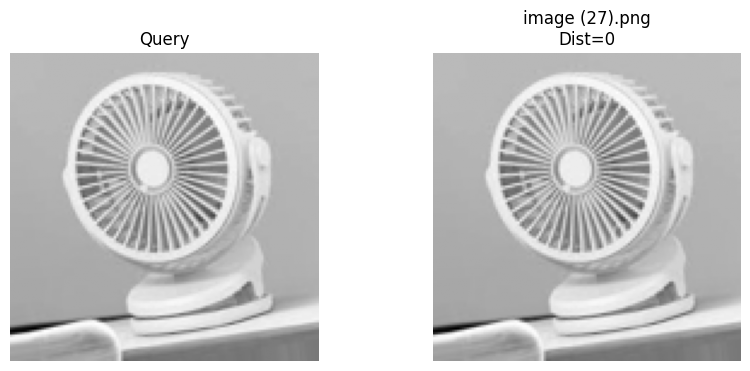

In [78]:
# SEARCH IMAGE
def search_image(image, wavelet, dataset, threshold):
    q_hash = wavelet_hash(image, wavelet)

    results = []
    for img in dataset:
        h = wavelet_hash(img, wavelet)
        dist = hamming_distance(q_hash, h)
        results.append((img, dist))

    # Sắp xếp theo độ giống
    results.sort(key=lambda x: x[1])

    # Lọc ảnh giống
    similar = [r for r in results if r[1] < threshold]

    return results, similar


# Query

image = "image (27).png"

wavelet = "db4"

results, similar = search_image(image, wavelet, images, 100)

# ===== In kết quả =====
print("\n===== IMAGE SEARCH =====")
for r in results:
    print(f"Image: {r[0]} | Distance: {r[1]}")

print("\n===== SIMILAR IMAGES =====")
for r in similar:
    print(f"Image: {r[0]} | Distance: {r[1]}")


# ===== HIỂN THỊ ẢNH =====
plt.figure(figsize=(10,4))

# Query
plt.subplot(1, len(similar)+1, 1)
plt.imshow(load_image(image), cmap='gray')
plt.title("Query")
plt.axis('off')

# Kết quả giống
for i, (img_path, dist) in enumerate(similar):
    plt.subplot(1, len(similar)+1, i+2)
    plt.imshow(load_image(img_path), cmap='gray')
    plt.title(f"{img_path}\nDist={dist}")
    plt.axis('off')

plt.show()